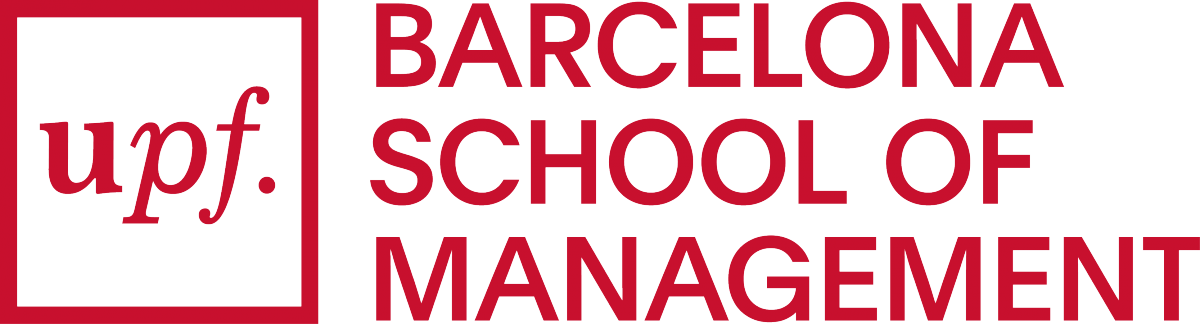

# Reto de Inteligencia Artificial

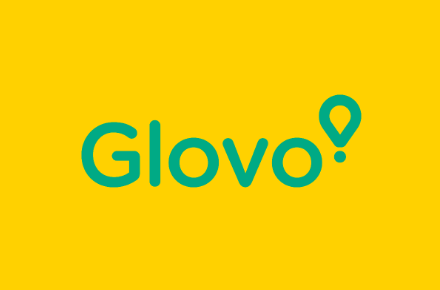

Gustavo Salazar

## Objetivo

**Proporcionar al cliente una estimación del tiempo que tomará un pedido (potencial).**

<h6>ETA: Estimated Time Arrival</h6>

In [ ]:
!pip install pandas==3.0

In [ ]:
csv: str = 'https://huggingface.co/datasets/gsv24/glovo-ops/resolve/main/glovo_ops_data_final.csv'

In [ ]:
import pandas as pd
import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots
import numpy as np
import math
import re
from joblib import parallel_backend

In [ ]:
pd.options.plotting.backend='plotly'

In [ ]:
ds: pd.DataFrame = pd.read_csv(
    filepath_or_buffer = csv,
    engine= 'c'
)

In [ ]:
df: pd.DataFrame = ds.copy()

## EDA

In [ ]:
df.tail()

,order_id,customer_id,courier_id,store_address_id,store_name,vertical,gtv,delivery_fee,description,activation_time_local,...,pickup_time_local,delivery_time_local,tranport_type,rating,bad_rating_reason,pickup_latitude,pickup_longitude,delivery_latitude,delivery_longitude,saturation
63641,51602.0,1297295,92.0,60709.0,Aux Merveilleux de Fred,WALL - NonPartner,30.3,6.9,2 x L’ Impensable - Mini\n2 x Le Merveilleux ...,2019-11-23 10:28:51.000,...,2019-11-23 11:04:19.883,2019-11-23 11:20:22.000,MOTORBIKE,NaN,NaN,48.844928,2.237055,48.819739,2.257546,96
63642,814.0,20092243,97.0,13198.0,Benson Kfé,WALL - Partner,21.9,3.9,1 x Chicken,2019-10-02 12:00:35.000,...,2019-10-02 12:12:21.561,2019-10-02 12:37:06.000,MOTORBIKE,NaN,NaN,48.878383,2.285877,48.892718,2.238183,103
63643,81638.0,6234499,59.0,NaN,NaN,COURIER,11.9,11.9,Une livraison à 15h au 1 TER CITÉ GERMAIN PILO...,2019-12-25 13:39:32.000,...,2019-12-25 13:49:32.407,2019-12-25 14:05:28.000,BICYCLE,5.0,NaN,48.865610,2.342366,48.880040,2.332157,48
63644,65757.0,8452912,402.0,NaN,NaN,COURIER,12.9,12.9,Lunettes,2019-12-06 13:02:10.000,...,2019-12-06 13:30:59.134,2019-12-06 14:03:18.000,BICYCLE,5.0,NaN,48.874409,2.332547,48.886671,2.284347,109
63645,72356.0,10952986,54.0,47793.0,Helles Paris,WALL - Partner,32.9,3.9,1 x Créoles Idylle,2019-12-13 15:33:17.000,...,2019-12-13 15:48:37.313,2019-12-13 16:11:25.000,BICYCLE,NaN,NaN,48.868612,2.281514,48.848190,2.262734,47


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 63646 entries, 0 to 63645
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   order_id                     63646 non-null  float64
 1   customer_id                  63646 non-null  int64  
 2   courier_id                   63646 non-null  float64
 3   store_address_id             52018 non-null  float64
 4   store_name                   52018 non-null  str    
 5   vertical                     63646 non-null  str    
 6   gtv                          63646 non-null  float64
 7   delivery_fee                 63646 non-null  float64
 8   description                  63614 non-null  str    
 9   activation_time_local        63646 non-null  str    
 10  courier_started_order_local  63642 non-null  str    
 11  pickup_time_local            63646 non-null  str    
 12  delivery_time_local          63646 non-null  str    
 13  tranport_type              

In [ ]:
df.isna().sum().to_frame('Nulos')

,Nulos
order_id,0
customer_id,0
courier_id,0
store_address_id,11628
store_name,11628
vertical,0
gtv,0
delivery_fee,0
description,32
activation_time_local,0


In [ ]:
df.describe()

,order_id,customer_id,courier_id,store_address_id,gtv,delivery_fee,rating,pickup_latitude,pickup_longitude,delivery_latitude,delivery_longitude,saturation
count,63646.000000,6.364600e+04,63646.000000,52018.000000,63646.000000,63646.000000,26784.000000,63646.000000,63646.000000,63646.000000,63646.000000,63646.000000
mean,42599.441033,7.339444e+06,281.304183,42794.678477,23.475663,5.569971,4.820154,48.864058,2.321907,48.864130,2.318299,77.772633
std,24605.798877,8.219375e+06,140.223522,41522.426586,17.365952,3.661555,0.827880,0.017255,0.037469,0.020156,0.040682,36.107480
min,1.000000,1.154000e+03,1.000000,911.000000,0.000000,0.000000,1.000000,48.803918,2.221335,48.794007,2.211807,20.000000
25%,21298.250000,1.094467e+06,165.000000,7113.000000,12.900000,3.900000,5.000000,48.852065,2.289582,48.850450,2.287040,51.000000
50%,42649.500000,3.209173e+06,303.000000,23886.000000,18.390000,3.900000,5.000000,48.866397,2.322111,48.865338,2.314835,73.000000
75%,63922.750000,1.167532e+07,403.000000,78604.000000,28.500000,6.900000,5.000000,48.876436,2.349763,48.878739,2.348273,98.000000
max,85126.000000,2.986686e+07,534.000000,136345.000000,346.620000,23.900000,5.000000,48.916104,2.437825,48.928184,2.443143,239.000000


In [ ]:
df.select_dtypes('str').describe()

,store_name,vertical,description,activation_time_local,courier_started_order_local,pickup_time_local,delivery_time_local,tranport_type,bad_rating_reason
count,52018,63646,63614,63646,63642,63646,63646,63646,2513
unique,567,3,49577,63332,63642,63644,63184,4,68
top,Carrefour,WALL - Partner,Un sac,2019-11-23 19:14:24.000,2019-10-01 09:19:06.342,2019-10-17 20:55:41.589,2019-11-18 21:11:26.000,MOTORBIKE,WRONG_OR_MISSING_PRODUCT
freq,9749,42116,415,3,1,2,3,34750,1200


### Información del Dataset

Dataset con 63.645 registros.

| Columna | Nombre | Descripción |
| :--- | :--- | :--- |
| `order_id` | ID del Pedido | ID único de orden. |
| `customer_id` | ID del Cliente | ID usuario. |
| `courier_id` | ID del Repartidor | ID repartidor.  |
| `store_address_id` | ID de Dirección de Tienda | ID ubicación física tienda. **11,628 nulls** |
| `store_name` | Nombre de la Tienda | Nombre tienda. **11,628 nulls**  |
| `vertical` | Categoría de Negocio | Categoría negocio |
| `gtv` | Valor Bruto de Transacción | Valor bruto transacción |
| `delivery_fee` | Tarifa de Envío | Tarifa entrega cobrada al cliente |
| `description` | Descripción | Contenido del pedido. **32 nulls** |
| `activation_time_local` | Hora Local de Activación | Timestamp cuando pedido entra al sistema (cliente hace el pedido). |
| `courier_started_order_local` | Hora Local Inicio de Repartidor | Timestamp cuando repartidor acepta/inicia el pedido. **4 nulls.**  |
| `pickup_time_local` | Hora Local de Recogida | Timestamp cuando repartidor acepta/inicia el pedido. **4 nulls.**  |
| `delivery_time_local` | Hora Local de Entrega | Timestamp entrega final al cliente. Sin nulls. |
| `tranport_type` | Tipo de Transporte | Vehículo del repartidor. (tranport sin s). |
| `rating` | Calificación | Calificación del cliente. **36862 nulls** |
| `bad_rating_reason` | Motivo de Mala Calificación | Razones mala calificación. **61133 nulls** |
| `pickup_latitude` | Latitud de Recogida | Lat coordenada tienda/origen. |
| `pickup_longitude` | Longitud de Recogida | Lon coordenada tienda/origen.  |
| `delivery_latitude` | Latitud de Entrega | Lat coordenada entrega cliente. |
| `delivery_longitude` | Longitud de Entrega | Lon coordenada entrega cliente.  |
| `saturation` | Saturación | Nivel demanda zona al momento del pedido. |

In [ ]:
df['lat_r'] = df['pickup_latitude'].round(3)
df['lon_r'] = df['pickup_longitude'].round(3)

agg = df.groupby(['lat_r', 'lon_r']).agg(
    order_count=('order_id', 'count'),
    saturation=('saturation', 'mean'),
    store_name=('store_name', lambda x: x.dropna().mode()[0] if len(x.dropna()) > 0 else 'Unknown')
).reset_index()

fig = go.Figure(go.Scattermap(
    lat=agg['lat_r'],
    lon=agg['lon_r'],
    mode='markers',
    marker=dict(
        size=agg['order_count'].apply(lambda v: max(2, v**0.5 * 0.6)),
        color=agg['saturation'],
        colorscale='YlOrRd',
        colorbar=dict(title='Órdenes'),
        opacity=0.8,
    ),
    text=agg['store_name'] + '<br>Órdenes: ' + agg['order_count'].astype(str),
    hoverinfo='text',
)
               )

fig.update_layout(
    map=dict(
        style='light',
        center=dict(lat=48.864, lon=2.327),
        zoom=12
    )
)

fig.show()

Variables `Timestamp`

In [ ]:
timestamp = ['activation_time_local',
'courier_started_order_local',
'pickup_time_local',
'delivery_time_local']

for col in timestamp:
    df[col]=pd.to_datetime(df[col])

In [ ]:
num_cols = df.select_dtypes('number').columns

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig = make_subplots(
    rows=n_rows,
    cols=n_cols,
    subplot_titles=num_cols,
    horizontal_spacing=0.08,
    vertical_spacing=0.12
)

colors = [
    '#e94560', '#4da8da', '#45f5a5', '#f5c542', '#bb86fc', '#ff6b6b', '#1dd1a1',
    '#ff9f43', '#54a0ff', '#5f27cd', '#00d2d3', '#ff4757', '#2ed573', '#ffa502'
]

for i, col in enumerate(num_cols):
    row = i // n_cols + 1
    col_pos = i % n_cols + 1

    fig.add_trace(
        go.Histogram(
            x=df[col],
            nbinsx=25,
            marker_color=colors[i % len(colors)],
            marker_line_color='black',
            marker_line_width=0.5,
            opacity=0.85,
            showlegend=False
        ),
        row=row, col=col_pos
    )

    mean_val = df[col].mean()
    fig.add_vline(
        x=mean_val,
        line_dash='dash',
        line_color='white',
        line_width=1.5,
        annotation_text=f'μ={mean_val:.1f}',
        annotation_font_color='white',
        annotation_font_size=10,
        row=row, col=col_pos
    )

fig.update_layout(
    title_text='Distribución de variables numéricas.',
    font=dict(color='white'),
    title_font_size=20,
    height=300 * n_rows,
    template='seaborn',
    paper_bgcolor='#0f0f1a',
    plot_bgcolor='#1a1a2e',
)

fig.update_xaxes(
    gridcolor='#2a2a4a',
    zerolinecolor='#444',
    linecolor='#888',
    tickfont=dict(color='white'),
    title_font=dict(color='white')
)

fig.update_yaxes(
    gridcolor='#2a2a4a',
    zerolinecolor='#444',
    linecolor='#888',
    tickfont=dict(color='white'),
    title_font=dict(color='white')
)


fig.show()

In [ ]:
num_cols = ['gtv','delivery_fee','saturation']

# Grid config
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig = make_subplots(
    rows=n_rows,
    cols=n_cols,
    subplot_titles=num_cols,
    horizontal_spacing=0.08,
    vertical_spacing=0.12
)

colors = [
    '#e94560', '#4da8da', '#45f5a5', '#f5c542', '#bb86fc', '#ff6b6b', '#1dd1a1',
    '#ff9f43', '#54a0ff', '#5f27cd', '#00d2d3', '#ff4757', '#2ed573', '#ffa502'
]

for i, col in enumerate(num_cols):
    row = i // n_cols + 1
    col_pos = i % n_cols + 1

    fig.add_trace(
        go.Histogram(
            x=df[col],
            nbinsx=25,
            marker_color=colors[i % len(colors)],
            marker_line_color='black',
            marker_line_width=0.5,
            opacity=0.85,
            showlegend=False
        ),
        row=row, col=col_pos
    )

    mean_val = df[col].mean()
    fig.add_vline(
        x=mean_val,
        line_dash='dash',
        line_color='white',
        line_width=1.5,
        annotation_text=f'μ={mean_val:.1f}',
        annotation_font_color='white',
        annotation_font_size=10,
        row=row, col=col_pos
    )

fig.update_layout(
    title_text='Distribución de variables numéricas.',
    font=dict(color='white'),
    title_font_size=20,
    height=300 * n_rows,
    template='seaborn',
    paper_bgcolor='#0f0f1a',
    plot_bgcolor='#1a1a2e',
)

fig.update_xaxes(
    gridcolor='#2a2a4a',
    zerolinecolor='#444',
    linecolor='#888',
    tickfont=dict(color='white'),
    title_font=dict(color='white')
)

fig.update_yaxes(
    gridcolor='#2a2a4a',
    zerolinecolor='#444',
    linecolor='#888',
    tickfont=dict(color='white'),
    title_font=dict(color='white')
)


fig.show()

In [ ]:
import ipywidgets as widgets
from IPython.display import display

cat_cols = ['store_name',
 'vertical',
 'description',
 'tranport_type',
 'bad_rating_reason',
 'rating',
 'order_id',
 'customer_id']
def plot_col(col):
    i = cat_cols.index(col)
    counts = df[col].value_counts(dropna=False).head(15)
    x_labels = [str(x)[:30] + '...' if len(str(x)) > 30 else str(x) for x in counts.index]

    fig = go.Figure(go.Bar(
        x=x_labels,
        y=counts.values,
        marker_color=colors[i % len(colors)],
        marker_line_color='white',
        marker_line_width=0.5,
        opacity=0.85,
        text=[f'{v}  ({v/len(df)*100:.1f}%)' for v in counts.values],
        textposition='auto',
        textfont=dict(size=10, color='white')
    ))
    fig.update_layout(
        title_text=f'Distribución: {col}',
        title_font_size=16,
        height=450,
        template='plotly_dark',
        paper_bgcolor='#0f0f1a',
        plot_bgcolor='#1a1a2e',
        font=dict(color='white'),
        xaxis=dict(gridcolor='#2a2a4a', tickangle=-30, tickfont=dict(color='white')),
        yaxis=dict(gridcolor='#2a2a4a', tickfont=dict(color='white'))
    )
    fig.show()

dropdown = widgets.Dropdown(options=cat_cols, description='Column:')
widgets.interact(plot_col, col=dropdown)

interactive(children=(Dropdown(description='Column:', options=('store_name', 'vertical', 'description', 'tranp…

<function __main__.plot_col(col)>

In [ ]:
time_cols = df.select_dtypes('datetime64').columns

df[time_cols].agg(['min', 'max'])

,activation_time_local,courier_started_order_local,pickup_time_local,delivery_time_local
min,2019-10-01 08:32:08,2019-10-01 08:58:42.736,2019-10-01 09:08:09.822,2019-10-01 09:25:32
max,2019-12-30 23:22:58,2019-12-30 23:22:25.338,2019-12-30 23:49:03.435,2019-12-30 23:59:29


In [ ]:
((df[time_cols].agg(['min', 'max'])).iloc[1]).iloc[1] - ((df[time_cols].agg(['min', 'max'])).iloc[0]).iloc[0]

Timedelta('90 days 14:50:17.338000')

### Hallazgos

- Datos de París, Francia.
- 90 días de datos.
- **Valor bruto promedio** de transacción: 23,5€.
- **Tarifa promedio** de envío: 5,6€.
    -  mayormente la tarifa de envío es de 3,9€.
- **Saturación promedio** de 77,8 puntos.
- Existe *una gran parte de información faltante* del comercio del cual se realizó la orden.
- Hay una **gran cantidad de órdenes de Carrefour**.
- El tipo de comercio que mayor existe es de **"Partners"**.
- La mayoría de pedidos son en **moto**.
- Existen *muchos valores núlos* en la razón de de un mala reseña.
    - Seguido a ello, la **mayor queja** es en un producto incorrecto o faltante
- Mayoría de valores *nulos en "rating*"
    - Tras ello, la mayor parte de órdenes tienen **5 estrellas**.

<h6>Existe un usuario que representa el 3.2% de las órdenes<h6>

### Variables Nulas

In [ ]:
df.isnull().sum()

order_id                           0
customer_id                        0
courier_id                         0
store_address_id               11628
store_name                     11628
vertical                           0
gtv                                0
delivery_fee                       0
description                       32
activation_time_local              0
courier_started_order_local        4
pickup_time_local                  0
delivery_time_local                0
tranport_type                      0
rating                         36862
bad_rating_reason              61133
pickup_latitude                    0
pickup_longitude                   0
delivery_latitude                  0
delivery_longitude                 0
saturation                         0
lat_r                              0
lon_r                              0
dtype: int64

In [ ]:
df.isnull().sum()/len(df) * 100

order_id                        0.000000
customer_id                     0.000000
courier_id                      0.000000
store_address_id               18.269805
store_name                     18.269805
vertical                        0.000000
gtv                             0.000000
delivery_fee                    0.000000
description                     0.050278
activation_time_local           0.000000
courier_started_order_local     0.006285
pickup_time_local               0.000000
delivery_time_local             0.000000
tranport_type                   0.000000
rating                         57.917230
bad_rating_reason              96.051598
pickup_latitude                 0.000000
pickup_longitude                0.000000
delivery_latitude               0.000000
delivery_longitude              0.000000
saturation                      0.000000
lat_r                           0.000000
lon_r                           0.000000
dtype: float64

In [ ]:
df['description'].isnull().sum() / len(df) * 100

np.float64(0.05027810074474437)

In [ ]:
df['rating'].value_counts(dropna=False, normalize=True) * 100

rating
NaN    57.917230
5.0    40.173774
1.0     1.885429
4.0     0.021997
2.0     0.001571
Name: proportion, dtype: float64

In [ ]:
df[df['rating'] < 5]['bad_rating_reason'].value_counts(dropna=False)

bad_rating_reason
NaN                                                                                           404
UNPROFESSIONAL_GLOVER                                                                         133
TOOK_TOO_LONG                                                                                 119
BAD_PRODUCT_HANDLING,WRONG_OR_MISSING_PRODUCT                                                  90
BAD_PRODUCT_HANDLING                                                                           78
                                                                                             ... 
ORDER_NOT_DELIVERED,PAYMENT_PROBLEM                                                             1
BAD_PRODUCT_QUALITY,PAYMENT_PROBLEM,PRICING_PROBLEM,TOOK_TOO_LONG,WRONG_OR_MISSING_PRODUCT      1
BAD_PRODUCT_QUALITY,ORDER_NOT_DELIVERED,UNPROFESSIONAL_GLOVER                                   1
BAD_PRODUCT_QUALITY,ORDER_NOT_DELIVERED,TOOK_TOO_LONG                                           1
OR

In [ ]:
df[df['store_name'].isnull()]['vertical'].value_counts()

vertical
COURIER    11628
Name: count, dtype: int64

In [ ]:
df[df['courier_started_order_local'].isnull()][['vertical', 'tranport_type', 'pickup_time_local', 'delivery_time_local']]

,vertical,tranport_type,pickup_time_local,delivery_time_local
7080,WALL - Partner,MOTORBIKE,2019-10-27 21:26:45.167,2019-10-27 21:48:11
37321,WALL - Partner,MOTORBIKE,2019-11-12 18:34:27.869,2019-11-12 18:44:03
40219,WALL - Partner,MOTORBIKE,2019-10-19 16:49:06.981,2019-10-19 16:58:42
46047,WALL - Partner,MOTORBIKE,2019-12-09 21:54:09.629,2019-12-09 22:02:49


El uso de valores núlos tiene sentido en las distintas columnas. Tal es el caso de `store_name` del cual no tiene ninguna tienda debido a que el tipo de envío realizado era de mensajería.

Solo existen cuatro valores de `courier_started_order_local` los cuales podrían ser retirados previo a la realización del pipeline.

### Consumo en órdenes.

In [ ]:
pronouns = [
    "je", "tu", "il", "elle", "on", "nous", "vous", "ils", "elles",
    "me", "te", "se", "moi", "toi", "lui", "leur", "eux",
    "le", "la", "les", "l'", "y", "en","’", 'à', 'au', 'une', 'de', ",", "€", 'g', 'ml'
]

In [ ]:
products = df.description

In [ ]:
products = products.str.lower()

In [ ]:
pattern = r"\b(" + "|".join(pronouns) + r")\b"

In [ ]:
products = products.str.replace(r"\d+\s*x", "", regex=True)
products = products.str.replace(r"\n+", " ", regex=True)
products = products.str.replace(r"-", " ", regex=True)
products = products.str.replace(pattern, "", regex=True)
products = products.str.replace(r"\d+", "", regex=True)
products = products.str.replace(r"€\s*", "", regex=True)
products = products.str.replace(r"g", "", regex=True)
products = products.str.replace(r"x", "", regex=True)
products = products.str.replace(r"cl", "", regex=True)
products = products.str.replace(r"[:：]", "", regex=True)
products = products.str.replace(r"\(", "", regex=True)
products = products.str.replace(r"\,", "", regex=True)
products = products.str.replace(r"(et)", "", regex=True)
products = products.str.replace(r"(l)", "", regex=True)
products = products.str.replace(r"(d)", "", regex=True)
products = products.str.replace(r"('l)", "", regex=True)

In [ ]:
products = products.str.split()

In [ ]:
products

0        [oiprane, m, comprimés, imoium, m, éues, smect...
1        [caffe, atte, ta, espresso, roast, assique, ae...
2        [venti, atte, vanie, ace, avec, seuement, pomp...
3                                                  [untes]
4        [emmenta, rape, %, franpri, pack, coca, coa, i...
                               ...                        
63641    [’, impensabe, mini, merveieu, mini, merveieu,...
63642                                            [chicken]
63643            [ivraison, à, h, ter, cité, ermain, pion]
63644                                              [untes]
63645                                        [créoes, iye]
Name: description, Length: 63646, dtype: object

In [ ]:
products.explode().value_counts().head(15).plot.bar()

Dado que la mayor cantidad de órdenes son de Carrefour a través de glovo, muchos de los productos que se piden son de la misma tienda.

### Saturación en semana.

In [ ]:
copy_set = df.copy()

In [ ]:
datetime_cols = [
    'activation_time_local',
    'courier_started_order_local',
    'pickup_time_local',
    'delivery_time_local'
]

for col in datetime_cols:
    copy_set[f'weekday_{col}'] = copy_set[col].dt.day_name()
    copy_set[f'hour_{col}'] = copy_set[col].dt.hour

In [ ]:
def plot_col(col):
    df_grouped = (
        copy_set.groupby(by=f'weekday_{col}')['saturation']
        .sum()
        .to_frame('saturacion')
        .sort_values(by='saturacion', ascending=False)
    )

    fig = go.Figure(
        data=[
            go.Bar(
                x=df_grouped.index.astype(str),
                y=df_grouped['saturacion'],
                marker=dict(
                    color=df_grouped['saturacion'],
                    colorscale='Viridis',
                    colorbar=dict(title='Saturation')
                )
            )
        ]
    )

    fig.update_layout(
        title=f'Saturación por {col} por día de la semana',
        xaxis_title=col,
        yaxis_title='Saturation'
    )

    fig.show()

In [ ]:
dropdown = widgets.Dropdown(
    options=datetime_cols,
    description='Column:'
)

widgets.interact(plot_col, col=dropdown)

interactive(children=(Dropdown(description='Column:', options=('activation_time_local', 'courier_started_order…

<function __main__.plot_col(col)>

In [ ]:
def plot_col(col):
    df_grouped = (
        copy_set.groupby(by=f'hour_{col}')['saturation']
        .sum()
        .to_frame('saturacion')
        .sort_values(by='saturacion', ascending=False)
    )

    fig = go.Figure(
        data=[
            go.Bar(
                x=df_grouped.index.astype(str),
                y=df_grouped['saturacion'],
                marker=dict(
                    color=df_grouped['saturacion'],
                    colorscale='Viridis',
                    colorbar=dict(title='Saturation')
                )
            )
        ]
    )

    fig.update_layout(
        title=f'Saturación por {col} 24hrs',
        xaxis_title=col,
        yaxis_title='Saturation'
    )

    fig.show()

In [ ]:
dropdown = widgets.Dropdown(
    options=datetime_cols,
    description='Column:'
)

widgets.interact(plot_col, col=dropdown)

interactive(children=(Dropdown(description='Column:', options=('activation_time_local', 'courier_started_order…

<function __main__.plot_col(col)>

#### ETA

Se realiza el cálculo del ETA dada la diferencia de tiempo entre el pedido entregado y pedido solicitado; este siendo en minutos.

In [ ]:
df['eta'] = (
    df['delivery_time_local'] - df['activation_time_local']
).dt.total_seconds() / 60

In [ ]:
fig = px.scatter(
    df,
    x='saturation',
    y='eta',
    title='ETA vs Saturation',
    labels={'saturation': 'Saturation', 'total_time_min': 'ETA (min)'},
    opacity=0.4
)

fig.show()

Se puede apreciar que a mayor saturación, mayor ETA existe en los pedidos. **Esto será crucial.**

In [ ]:
df.eta.plot.hist()

In [ ]:
df.eta.describe()

count    63646.000000
mean        38.127949
std         15.639348
min          3.633333
25%         27.400000
50%         35.100000
75%         45.333333
max        136.600000
Name: eta, dtype: float64

En promedio un pedido tiene un tiempo de espera entre que se realiza y se entrega de 38 min.

Lo mínimo que un pedido tarda es de 3,63 minutos y un máximo de 2hrs y 16 minutos.

In [ ]:
print(df['eta'].quantile([0.95, 0.97, 0.99, 0.999]))

0.950     68.266667
0.970     75.844167
0.990     91.360833
0.999    115.472583
Name: eta, dtype: float64


In [ ]:
print((df['eta'] > 90).sum())
print((df['eta'] > 90).mean() * 100)  # %

709
1.1139741696257424


### Saturación

In [ ]:
df.saturation.describe()

count    63646.000000
mean        77.772633
std         36.107480
min         20.000000
25%         51.000000
50%         73.000000
75%         98.000000
max        239.000000
Name: saturation, dtype: float64

In [ ]:
df.saturation.plot.hist()

In [ ]:
print(df[['saturation', 'eta']].corr())
print(df.groupby('activation_time_local')['saturation'].nunique().describe())

            saturation       eta
saturation    1.000000  0.778418
eta           0.778418  1.000000
count    63332.000000
mean         1.004942
std          0.070352
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          3.000000
Name: saturation, dtype: float64


In [ ]:
print(df['saturation'].value_counts().head(20))

saturation
62    778
71    770
72    768
73    766
70    761
78    758
64    740
65    739
61    734
79    730
60    729
76    723
74    719
69    713
75    713
77    711
55    705
80    700
67    697
81    693
Name: count, dtype: int64


A pesar de desconocer la medición de la saturación, cada valor único por tiempo en que se pide una orden tiene 1 valor de saturación. De ser una variable medida después de un envío, podría considerarse como *target leakage*.
La saturación parece ser medida por zona, por lo que se descarta esto último.

## Feature Engineering

Se generan más features a partir del cálculo del ETA y de otras variables para tener el mayor número de features que iremos descartando.

#### Tiempos
Se busca tener el tiempo en horas y día de la semana del tiempo de activación y una bandera para saber si el pedido fue realizado en fin de semana.

In [ ]:
df['hour_of_day'] = df['activation_time_local'].dt.hour
df['day_of_week'] = df['activation_time_local'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

In [ ]:
df['is_lunch'] = df['hour_of_day'].between(12, 14).astype(int)
df['is_dinner'] = df['hour_of_day'].between(19, 22).astype(int)
df['month'] = df['activation_time_local'].dt.month
df['week_of_year'] = df['activation_time_local'].dt.isocalendar().week.astype(int)

In [ ]:
# ── VENTANA ESTÁTICA 5 MIN ────────────────────────────────────────────────────
df['time_window_5m'] = df['activation_time_local'].dt.floor('5min')
window_counts = df.groupby('time_window_5m').size().reset_index(name='orders_in_5m_window')
df = df.merge(window_counts, on='time_window_5m', how='left')
df = df.drop(columns=['time_window_5m'])

df_act = pd.DataFrame({'timestamp': df['activation_time_local'].astype('datetime64[us]'), 'order_diff': 1})
df_del  = pd.DataFrame({'timestamp': df['delivery_time_local'].astype('datetime64[us]'),  'order_diff': -1})
df_events = pd.concat([df_act, df_del]).sort_values('timestamp')
df_events['live_orders'] = df_events['order_diff'].cumsum()
df_events = df_events.drop_duplicates(subset=['timestamp'], keep='last')
df = df.sort_values('activation_time_local')
df = pd.merge_asof(
    df,
    df_events[['timestamp', 'live_orders']],
    left_on='activation_time_local',
    right_on='timestamp',
    direction='backward'
).drop(columns=['timestamp'])

#### Distancia y dirección

Se utiliza el cálculo de distancia con la **distancia Haversine**. Esta calcula la distancia *en línea recta* sobre la superficie de la Tierra entre dos coordenadas gráficas siguiendo la curvatura terrestre. Dado que no considera calles, tráfico, sentido de circulación o autopistas, esta distancia se utiliza como una **aproximación** de la distancia entre dos puntos.

Asimismo, se utiliza un factor de circuito, que considerando la ciudad y el método de transporte (París, moto) se toma como 1,3.

In [ ]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

PARIS_CIRCUITY = 1.3

df['delivery_distance_km'] = haversine(
    df['pickup_latitude'],
    df['pickup_longitude'],
    df['delivery_latitude'],
    df['delivery_longitude']
) * PARIS_CIRCUITY

Se calcula la dirección hacia donde van los pedidos dando ángulos de 0 a 360 grados.

In [ ]:
def calculate_bearing(lat1, lon1, lat2, lon2):
    lat1, lat2 = np.radians(lat1), np.radians(lat2)
    dlon = np.radians(lon2 - lon1)
    x = np.sin(dlon) * np.cos(lat2)
    y = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    bearing = np.degrees(np.arctan2(x, y))
    return (bearing + 360) % 360  # normalize 0-360

df['bearing'] = calculate_bearing(
    df['pickup_latitude'], df['pickup_longitude'],
    df['delivery_latitude'], df['delivery_longitude']
)

In [ ]:
df['bearing_sin'] = np.sin(np.radians(df['bearing']))
df['bearing_cos'] = np.cos(np.radians(df['bearing']))

#### Pedidos Batch

Un pedido batch es aquel del cual un repartidor carga teniendo una orden sin terminar.

In [ ]:
df = df.sort_values(['courier_id', 'courier_started_order_local']).reset_index(drop=True)

df['prev_delivery_time'] = df.groupby('courier_id')['delivery_time_local'].shift(1)

df['is_batched'] = (
    df['courier_started_order_local'] < df['prev_delivery_time']
).astype(int)

df = df.drop(columns=['prev_delivery_time'])

print('Batched orders:', df['is_batched'].sum(), f"({df['is_batched'].mean()*100:.1f}%)")
print(df[df['is_batched'] == 1][['courier_id', 'courier_started_order_local', 'delivery_time_local']].head())

Batched orders: 11327 (17.8%)
    courier_id courier_started_order_local delivery_time_local
26         2.0     2019-10-01 20:17:19.431 2019-10-01 20:44:36
30         2.0     2019-10-04 17:37:28.528 2019-10-04 18:14:52
31         2.0     2019-10-04 17:41:13.783 2019-10-04 18:30:16
35         2.0     2019-10-06 13:54:45.231 2019-10-06 14:56:47
37         2.0     2019-10-06 16:28:45.097 2019-10-06 17:01:50


A pesar de formar casi un 18% de los pedidos, se toma la bandera de si un pedido es batch para el modelaje.

#### Promedio histórico y órdenes por repartidor

In [ ]:
df = df.sort_values('activation_time_local').reset_index(drop=True)

df['courier_orders_today'] = (
    df.groupby(['courier_id', df['activation_time_local'].dt.date])['order_id']
    .transform(lambda x: np.arange(1, len(x) + 1))
)

df['store_order_count'] = (
    df.groupby('store_name')['order_id']
    .transform(lambda x: np.arange(1, len(x) + 1))
)

### Correlación

In [ ]:
corr_cols = [
    'eta', 'saturation', 'delivery_distance_km', 'gtv', 'delivery_fee',
    'hour_of_day', 'day_of_week', 'is_weekend', 'is_lunch', 'is_dinner',
    'month', 'week_of_year', 'is_batched',
    'bearing_sin', 'bearing_cos','courier_orders_today','store_order_count'
]

corr = df[corr_cols].corr()

fig = px.imshow(
    corr,
    text_auto='.2f',
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    title='Correlation Matrix'
)
fig.update_layout(width=1000, height=1000)

fig.show()

La saturación será la variable más fuerte para predecir nuestro ETA, seguido de la distancia que se toma, además del gtv y delivery_fee.

## Modelo

Como base de evaluación consideramos usar está métricas de evaluación:
*   MAE
*   MSE
*   R²

#### **Lasso (con GridSearch)**

In [ ]:
data = df[[
    'eta',
    'saturation', 'delivery_distance_km', 'delivery_fee', 'gtv',
    'hour_of_day', 'day_of_week',
    'is_batched', 'month', 'week_of_year',
    'bearing_sin', 'bearing_cos',
    'vertical', 'tranport_type',
    'courier_orders_today',
    'store_order_count',
    'orders_in_5m_window', 'live_orders'
]].copy()

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer


X = data.drop(columns='eta')
y = data['eta']

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
num_cols = [
    'saturation', 'delivery_distance_km', 'delivery_fee', 'gtv',
    'hour_of_day', 'day_of_week', 'is_batched', 'month', 'week_of_year',
    'bearing_sin', 'bearing_cos',
    'courier_orders_today', 'store_order_count',
    'orders_in_5m_window', 'live_orders'
]
cat_cols = ['vertical', 'tranport_type']


In [ ]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ]), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(random_state=42))
])

param_grid = {'model__alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]}

search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print(f"Best alpha: {search.best_params_['model__alpha']}")
print(f"Best CV MAE: {-search.best_score_:.3f}")

y_pred = search.predict(X_test)

print(f"\nTest MAE:  {mean_absolute_error(y_test, y_pred):.3f}")
print(f"Test RMSE: {mean_squared_error(y_test, y_pred)**.5:.3f}")
print(f"Test R2:   {r2_score(y_test, y_pred):.3f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best alpha: 0.01
Best CV MAE: 7.654

Test MAE:  7.765
Test RMSE: 9.646
Test R2:   0.655


#### **Random Forest (con Gridsearch)**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Pipeline
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

# Cross-val search
param_grid_rf = {
    'model__n_estimators': [50, 100],
    'model__max_depth': [5, 10, None],
    'model__min_samples_leaf': [5, 10]
}

rf_search = GridSearchCV(
    rf_pipeline,
    param_grid_rf,
    cv=4,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print(f"Best params: {rf_search.best_params_}")
print(f"Best CV MAE: {-rf_search.best_score_:.3f}")

y_pred_rf = rf_search.predict(X_test)

print(f"\nTest MAE:  {mean_absolute_error(y_test, y_pred_rf):.3f}")
print(f"Test RMSE: {mean_squared_error(y_test, y_pred_rf)**.5:.3f}")
print(f"Test R2:   {r2_score(y_test, y_pred_rf):.3f}")

Fitting 4 folds for each of 12 candidates, totalling 48 fits
Best params: {'model__max_depth': 10, 'model__min_samples_leaf': 10, 'model__n_estimators': 50}
Best CV MAE: 7.005

Test MAE:  7.223
Test RMSE: 9.014
Test R2:   0.699


#### **XGBoost (con GridSearch)**

In [ ]:
from xgboost import XGBRegressor

xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(random_state=42, n_jobs=-1))
])

param_grid_xgb = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 7],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0]
}

xgb_search = GridSearchCV(
    xgb_pipeline,
    param_grid_xgb,
    cv=4,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)

with parallel_backend('loky', n_jobs=2):
    xgb_search.fit(X_train, y_train)

print(f"Best params: {xgb_search.best_params_}")
print(f"Best CV MAE: {-xgb_search.best_score_:.3f}")

y_pred_xgb = xgb_search.predict(X_test)

print(f"\nTest MAE:  {mean_absolute_error(y_test, y_pred_xgb):.3f}")
print(f"Test RMSE: {mean_squared_error(y_test, y_pred_xgb)**.5:.3f}")
print(f"Test R2:   {r2_score(y_test, y_pred_xgb):.3f}")

Fitting 4 folds for each of 16 candidates, totalling 64 fits
Best params: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 0.8}
Best CV MAE: 6.947

Test MAE:  7.160
Test RMSE: 8.936
Test R2:   0.704


In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', HistGradientBoostingRegressor(random_state=42))
])

param_grid_hgb = {
    'model__max_iter': [100, 200],
    'model__max_depth': [3, 5, 10],
    'model__learning_rate': [0.05, 0.1],
    'model__min_samples_leaf': [10]
}

hgb_search = GridSearchCV(
    hgb_pipeline,
    param_grid_hgb,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=1,
    verbose=1
)

hgb_search.fit(X_train, y_train)

print(f"Best params: {hgb_search.best_params_}")
print(f"Best CV MAE: {-hgb_search.best_score_:.3f}")

y_pred_hgb = hgb_search.predict(X_test)

print(f"\nTest MAE:  {mean_absolute_error(y_test, y_pred_hgb):.3f}")
print(f"Test RMSE: {mean_squared_error(y_test, y_pred_hgb)**.5:.3f}")
print(f"Test R2:   {r2_score(y_test, y_pred_hgb):.3f}")

| Modelo | MAE | RMSE | R² |
|---|---|---|---|
| Lasso | 7.765 | 9.646 | 0.655 |
| Random Forest | 7.223 | 9.014 | 0.699 |
| XGBoost | **7.160** | **8.936** | **0.704** |
| HistGradientBoosting | 7.161 | 8.951 | 0.703 |

## Importancia de *features*

In [ ]:
ohe_features = (search.best_estimator_
                .named_steps['preprocessor']
                .named_transformers_['cat']
                .get_feature_names_out(cat_cols).tolist())

feature_names = num_cols + ohe_features
importances = xgb_search.best_estimator_.named_steps['model'].feature_importances_

feat_imp = (pd.DataFrame({'feature': feature_names, 'importance': importances})
            .sort_values('importance', ascending=False)
            .reset_index(drop=True))

print(feat_imp)

                       feature  importance
0                   saturation    0.762921
1         delivery_distance_km    0.061240
2      vertical_WALL - Partner    0.018701
3                          gtv    0.014562
4   vertical_WALL - NonPartner    0.013876
5         courier_orders_today    0.012766
6      tranport_type_MOTORBIKE    0.012323
7                  hour_of_day    0.011659
8                 delivery_fee    0.011571
9                   is_batched    0.009768
10           store_order_count    0.008479
11                 live_orders    0.008325
12                week_of_year    0.008148
13                 bearing_sin    0.007286
14                 day_of_week    0.007210
15                 bearing_cos    0.007036
16                       month    0.006801
17         orders_in_5m_window    0.006566
18           tranport_type_CAR    0.006472
19        tranport_type_WALKER    0.004289


In [ ]:
fig = px.bar(
    feat_imp,
    x='importance',
    y='feature',
    orientation='h',
    title='XGBoost Feature Importance',
    color='importance',
    color_continuous_scale='YlOrRd'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=600)
fig.show()

## Análisis Residual

In [ ]:
y_pred_xgb = xgb_search.predict(X_test)
residuals = y_test - y_pred_xgb

resid_df = X_test.copy()
resid_df['eta'] = y_test
resid_df['predicted'] = y_pred_xgb
resid_df['residual'] = residuals
resid_df['abs_residual'] = residuals.abs()

fig1 = px.scatter(
    resid_df,
    x='predicted',
    y='residual',
    opacity=0.4,
    title='Residuals vs Predicted',
    labels={'predicted': 'Predicted ETA (min)', 'residual': 'Residual (min)'}
)
fig1.add_hline(y=0, line_dash='dash', line_color='red')
fig1.show()

fig2 = px.histogram(
    resid_df,
    x='residual',
    nbins=50,
    title='Residual Distribution',
    labels={'residual': 'Residual (min)'}
)
fig2.add_vline(x=0, line_dash='dash', line_color='red')
fig2.show()

print("=== Peores 10 predicciones (highest abs error) ===")
print(resid_df.nlargest(10, 'abs_residual')[['eta', 'predicted', 'residual', 'saturation', 'delivery_distance_km']])

resid_df['saturation_bucket'] = pd.cut(resid_df['saturation'], bins=[0, 50, 100, 150, 239], labels=['low', 'mid', 'high', 'very_high'])
print("\n=== MAE por segmentación de saturación ===")
print(resid_df.groupby('saturation_bucket')['abs_residual'].mean().round(3))

=== Peores 10 predicciones (highest abs error) ===
              eta  predicted   residual  saturation  delivery_distance_km
61420   77.900000  45.101803  32.798197         109              3.994349
54550   86.366667  54.174061  32.192606         129              4.650336
61368   92.683333  60.533688  32.149646         135              4.848868
59897   76.000000  44.018959  31.981041         108              2.525477
55833  112.833333  80.917099  31.916234         177              1.366979
51254   94.016667  62.189289  31.827378         141              3.450670
54837   77.883333  46.838676  31.044657         116              2.346695
61665   60.783333  30.374557  30.408776          77              0.670121
58004   74.500000  44.217731  30.282269         100              4.463785
61631   68.816667  38.542679  30.273988          95              0.895037

=== MAE por segmentación de saturación ===
saturation_bucket
low          5.229
mid          7.480
high         8.052
very_high    8.7

In [ ]:
resid_df['eta_bucket'] = pd.cut(
    resid_df['eta'],
    bins=[0, 20, 30, 40, 50, 60, 75, 100, 140],
    labels=['0-20', '20-30', '30-40', '40-50', '50-60', '60-75', '75-100', '100+']
)

print("=== MAE por ETA ===")
print(resid_df.groupby('eta_bucket', observed=True)['abs_residual'].agg(['mean', 'count', 'median']).round(3))

=== MAE por ETA ===
              mean  count  median
eta_bucket                       
0-20        10.942    765  10.805
20-30        5.734   3007   5.171
30-40        5.018   3716   4.561
40-50        7.058   2528   6.691
50-60        9.787   1348   9.034
60-75       10.991    858   9.830
75-100      12.567    436  11.090
100+        13.137     72  11.324


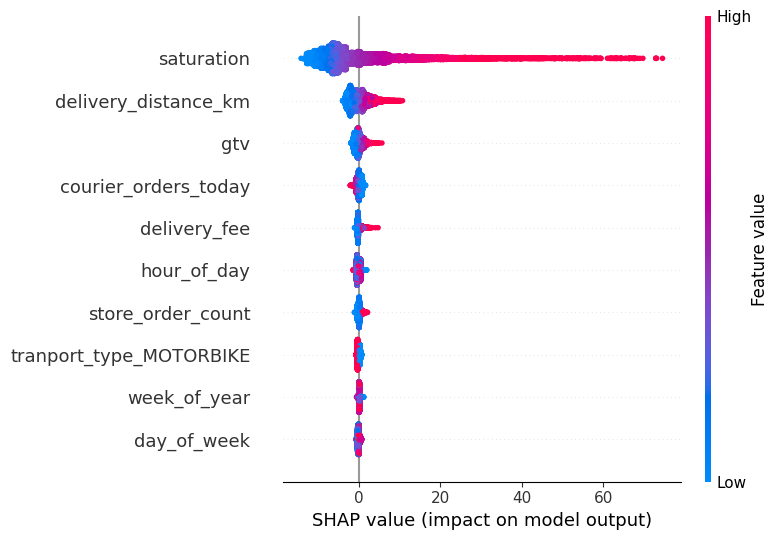

In [ ]:
import shap

best_xgb = xgb_search.best_estimator_.named_steps['model']
X_test_transformed = xgb_search.best_estimator_.named_steps['preprocessor'].transform(X_test)

ohe_features = (xgb_search.best_estimator_
                .named_steps['preprocessor']
                .named_transformers_['cat']
                .get_feature_names_out(cat_cols).tolist())
feature_names = num_cols + ohe_features

explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    max_display=10
)

## ETA

Asumiendo nuestro modelo de ML con XGboost, podemos utilizarlo para segmentar en grupos los tiempos de tardanza.

### ¿Por qué no un modelo de clasificación en vez de uno de regresión y después clasificación?

#### Flexibilidad
Los rangos pueden ser dentro de bloques que el negocio decida o incluso a partir de un modelo de clasificación para predicción de cuartiles.

#### Precisión
Se añade el tiempo estimado, junto con el rango.

#### Clasificación erronea
A diferencia de un modelo de clasificación, un pedido que cae con ETA de 31 min., cada categória es una caja aislad; no entiende que un grupo de 15-30 min. es físicamente cercano a 30-60 min. El modelo penaliza por si solo cada error.

### Segmentación

In [ ]:
bounds = resid_df.groupby('eta_bucket', observed=True)['residual'].agg(
    lower=lambda x: x.quantile(0.10),
    upper=lambda x: x.quantile(0.90)
).round(1)

print(bounds)

            lower  upper
eta_bucket              
0-20        -15.8   -6.1
20-30       -11.4    1.1
30-40        -8.7    7.4
40-50        -7.7   13.0
50-60        -7.8   18.8
60-75        -8.6   21.7
75-100       -7.9   24.6
100+          0.3   25.2


In [ ]:
resid_df['eta_bucket'] = pd.cut(
    resid_df['eta'],
    bins=[0, 20, 40, 75, 140],
    labels=['0-20', '20-40', '40-75', '75+']
)

print(resid_df.groupby('eta_bucket', observed=True)['abs_residual'].agg(['mean', 'count', 'median']).round(3))

print(resid_df.groupby('eta_bucket', observed=True)['residual'].agg(
    lower=lambda x: x.quantile(0.10),
    upper=lambda x: x.quantile(0.90)
).round(1))

              mean  count  median
eta_bucket                       
0-20        10.942    765  10.805
20-40        5.338   6723   4.773
40-75        8.548   4734   7.670
75+         12.648    508  11.115
            lower  upper
eta_bucket              
0-20        -15.8   -6.1
20-40       -10.4    5.8
40-75        -7.9   16.8
75+          -7.5   24.6


Tras tener una estimación específica, se puede tener con base a los estimados 4 grupos.

- 0-20 min.
- 20-40 min.
- 40-75 min.
- 75+ min.

#### **Puntos a considerar:**

- Se puede añadir un *bias* al tiempo de predicción, generando un "colchón" dentro del estimado del tiempo como estrategia de mercado. Un cliente se puede ver mayormente contento sabiendo que su orden con un ETA de 30 min, realmente tomó 25 min. o menos.

- CV: La configuración de *cross-validation* puede modificarse, los valores usados tomaron tiempo en calcularse, pero esto depende del cómputo y configuración.

- `saturation`: Hace falta definición de la saturación y explicación del cálculo detrás de la variable, tener escala de 20 a 239 es algo anormal o al menos no es una escala del 0 al 100%.

- Tiempo: De existir la temperatura y el clima que existió en ese día, podría ayudar a mejorar el modelo.

- Dataset con 90 días: Al ser un dataset de 90 días no existen patrones de estacionalidad, de los cuales pueden afectar a un ETA.

- Distancia: La distancia fue calculada a través de un método que no toma calles o sentido de circulación, es una simple línea recta; que aunada al factor de trayectoria genera una **aproximación**. Se podría utilizar una API de OpenStreet Maps o Google Maps.

## Conclusión

El modelo logra obtener un acierto en el 70% de los datos, logrando una medición de ETA aproximada a la realidad del tiempo medido que toma una orden entre pedirse y entregarse.

Es de considerar que el modelo tiene sus debilidades en puntos donde un pedido pueda tomar mucho tiempo al no tener factores de tardanza, de los cuales se podrían generar 2 modelos adicionales.

El primero para pedidos que tomen menos de los 20 min. y el segundo modelo, para pedidos que tomen más de la hora en entregarse.

Usando las 10 *features* que mayor contribuyen a un ETA:

* `saturation`: Es la variable dominante, en ella a mayor saturación existente, mayor existirá un tiempo estimado.

* `delivery_distance_km`: A mayor distancia, se afecta a más tiempo estimado de llegada.

* `gtv`: Mayor valor bruto de transacción, mayor ETA.

* `courier_orders_today`: Se puede interpretar a mayor cantidad de órdenes hechas en el día puede existir una "fatiga" y por lo tanto mayor tardanza, aunque esto no explica causalidad.

* `delivery_fee`: Mayor tarifa, mayor ETA

* `hour_of_day`: La hora del día se ve de forma mixta, esto puede deberse a momentos donde hay mayor demanda y por lo mismo un ETA más alto.

* `store_order_count`: Menor cantidad de comercios, mayor ETA.

* `transport_type_MOTORBIKE`: Es el medio más usado y al mismo tiempo reduce el ETA. Teniendo sentido al ser más rápido que un coche.

* `week_of_year` y `day_of_week`: Tienen un efecto muy mínimo en el ETA, puede llegar a ser solo ruido.
